<a href="https://colab.research.google.com/github/nigusalene2-cyber/MCP-ML-Project/blob/main/Montecarlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating synthetic MCP data...
Data shape: (1000, 12)

First few samples:
             field_type  deep_dose  shallow_dose  neutron_dose           L1  \
0     mixed_photon_beta  79.674644    170.664822      0.000000   782.820007   
1               neutron  96.993994    109.891970     48.831075   914.779570   
2                  beta  97.378176    225.401235      0.000000  1006.931868   
3         photon_medium  94.893665    112.567877      0.000000   919.683633   
4  mixed_photon_neutron  39.166955     34.188617     60.128587   363.398930   

            L2           L3           L4  ratio_L3_L2  ratio_L3_L1  \
0   842.871737  1641.198819   777.086170     1.947151     2.096521   
1   936.699747  1089.684846  1327.036840     1.163324     1.191199   
2   934.428035  2246.226902  1009.282472     2.403852     2.230764   
3  1010.487817  1152.467544   918.679777     1.140506     1.253113   
4   393.995268   338.663004   992.845048     0.859561     0.931932   

   ratio_L2_L4  ratio_L1_L2 

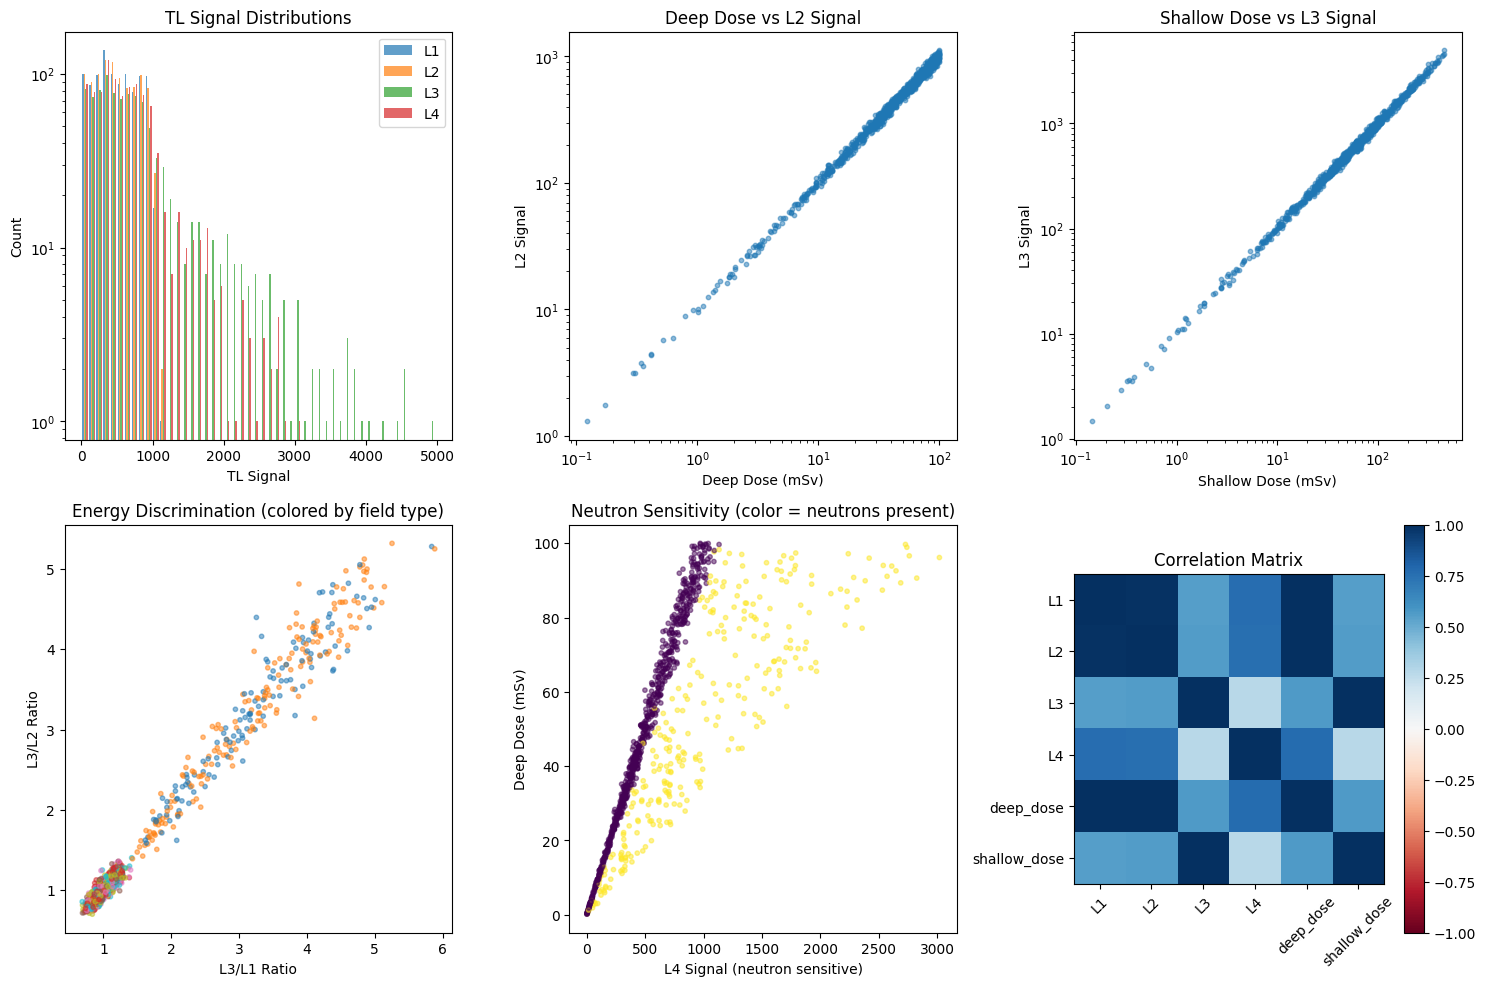


Training set size: 800
Test set size: 200

MONTE CARLO SIMULATION RESULTS

--- Random Forest ---
Running 100 Monte Carlo iterations...
Mean MAE: 1.6383 ± 0.0702 mSv
Mean RMSE: 2.1636 ± 0.0963 mSv
Mean R²: 0.9942 ± 0.0005
95% CI for MAE: [1.5286, 1.7521]


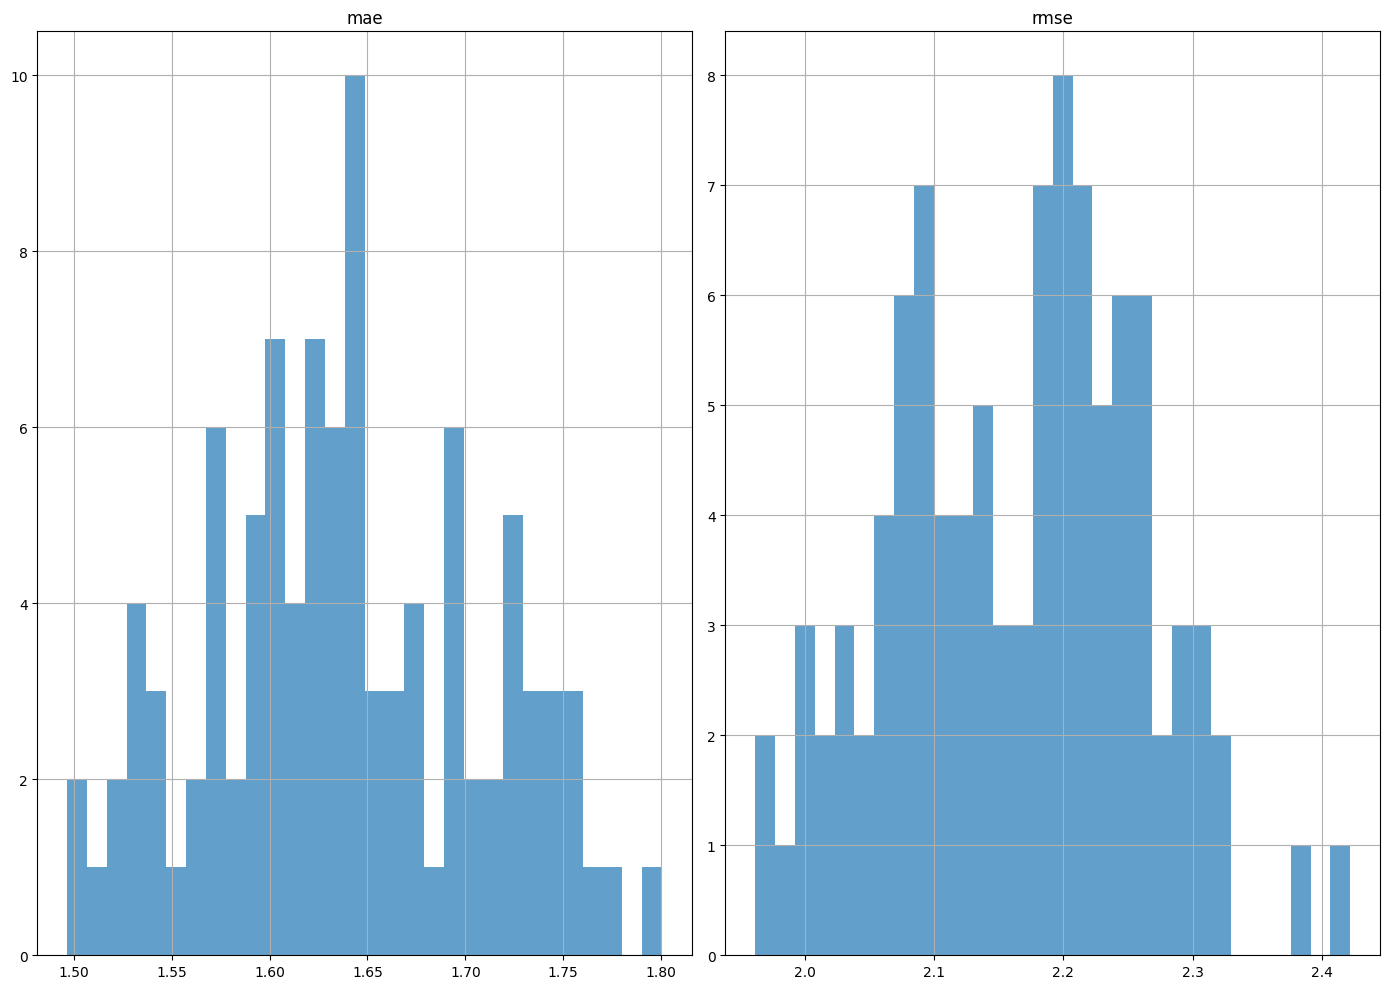


--- Gradient Boosting ---
Running 100 Monte Carlo iterations...
Mean MAE: 1.5714 ± 0.0607 mSv
Mean RMSE: 2.0663 ± 0.0811 mSv
Mean R²: 0.9947 ± 0.0004
95% CI for MAE: [1.4752, 1.6684]


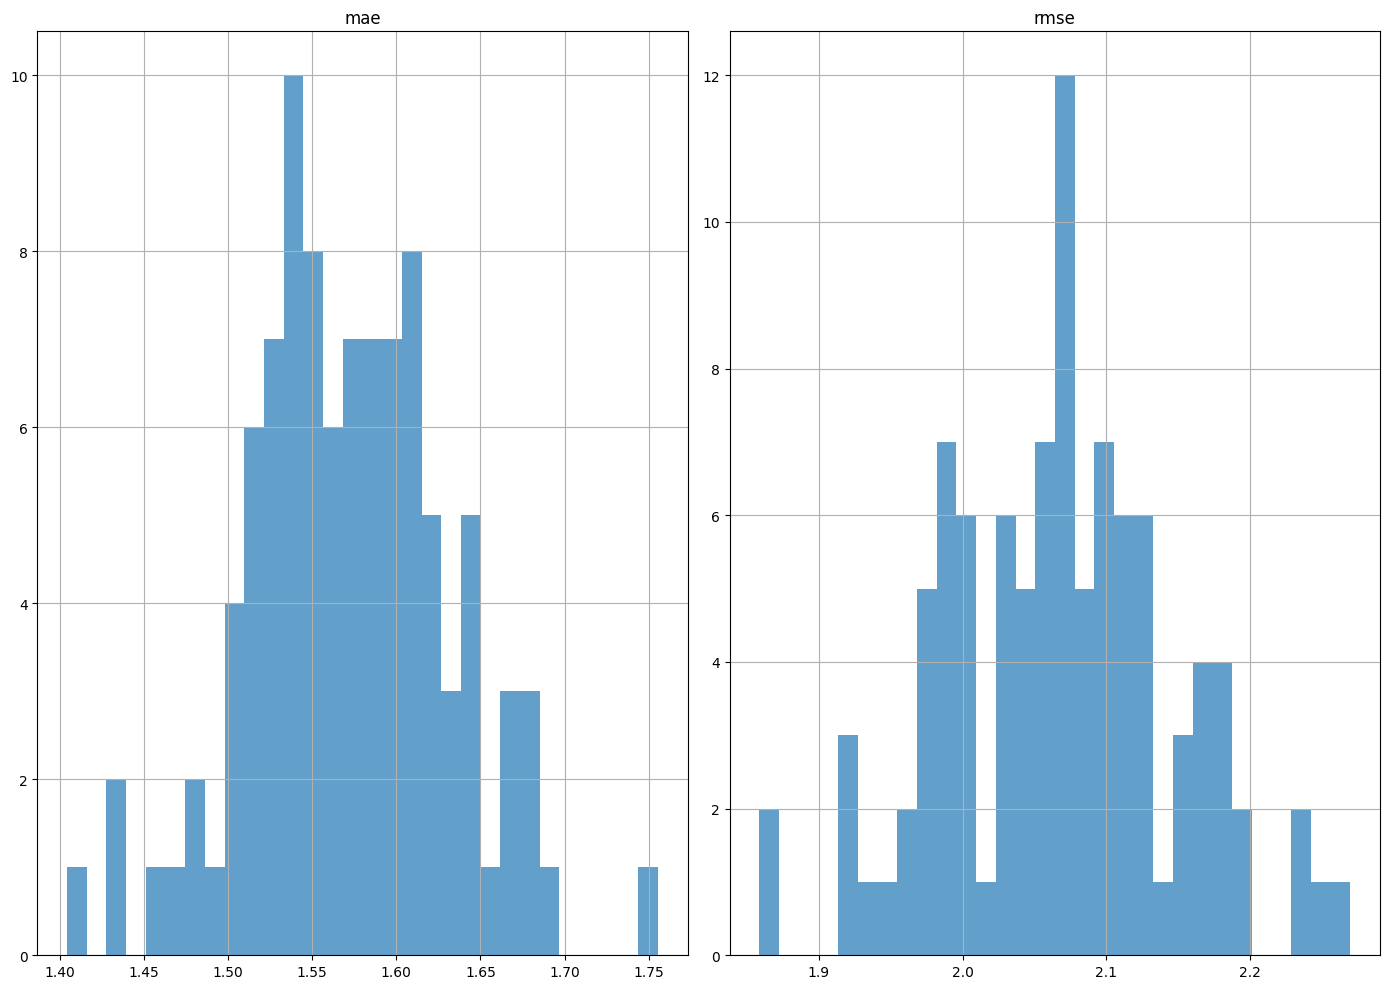


--- Ridge ---
Running 100 Monte Carlo iterations...
Mean MAE: 1.5549 ± 0.0346 mSv
Mean RMSE: 2.1170 ± 0.0354 mSv
Mean R²: 0.9945 ± 0.0002
95% CI for MAE: [1.5048, 1.6183]


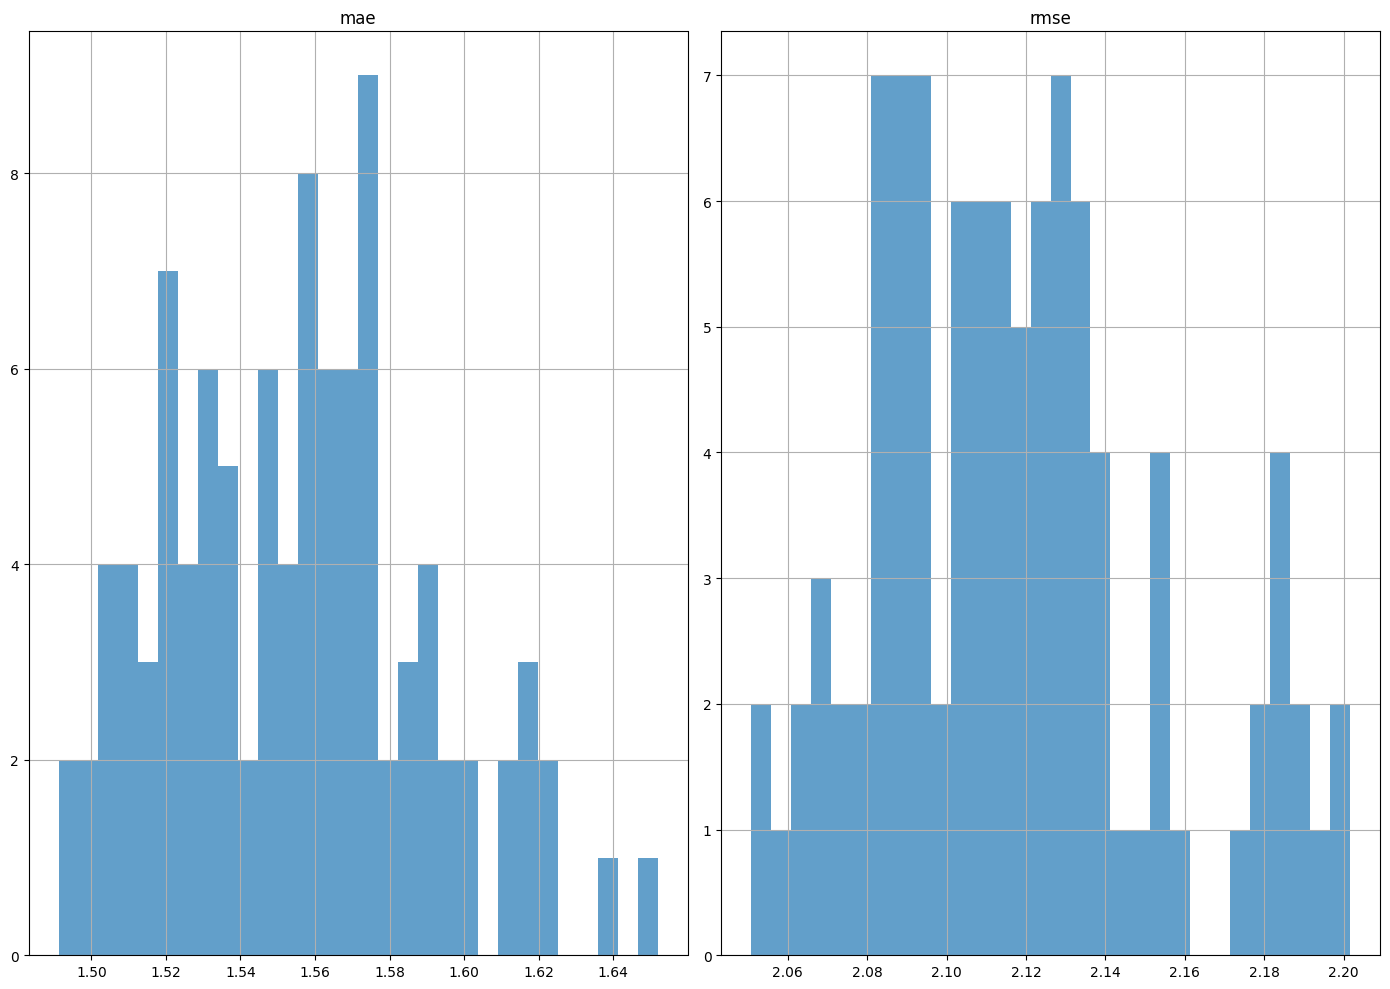


--- Neural Network ---
Running 100 Monte Carlo iterations...
Mean MAE: 1.4968 ± 0.0469 mSv
Mean RMSE: 2.0266 ± 0.0513 mSv
Mean R²: 0.9949 ± 0.0003
95% CI for MAE: [1.4208, 1.5788]


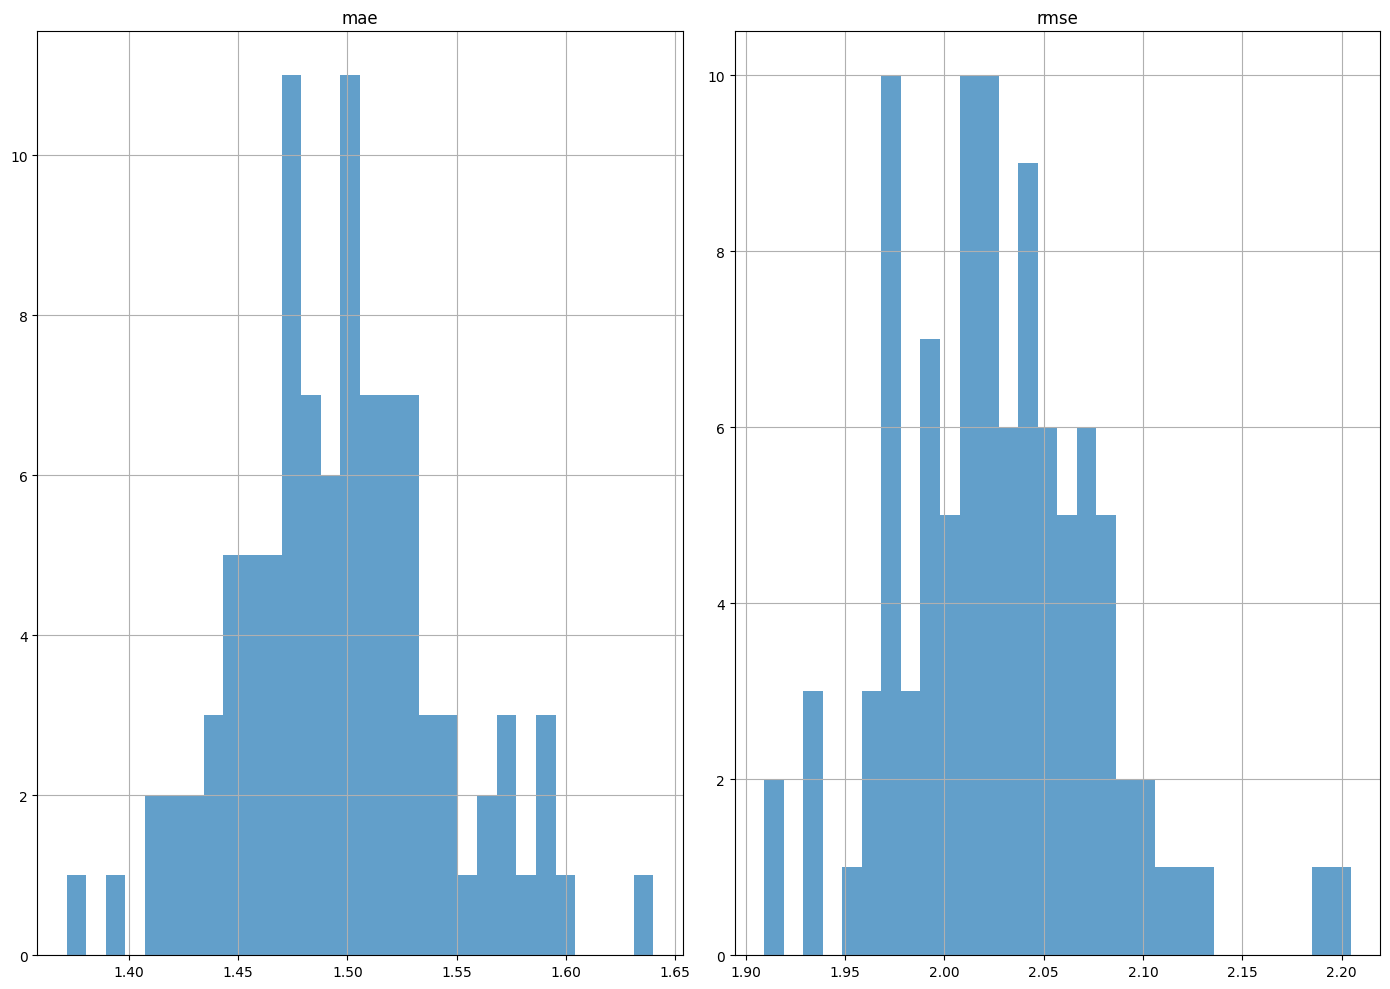

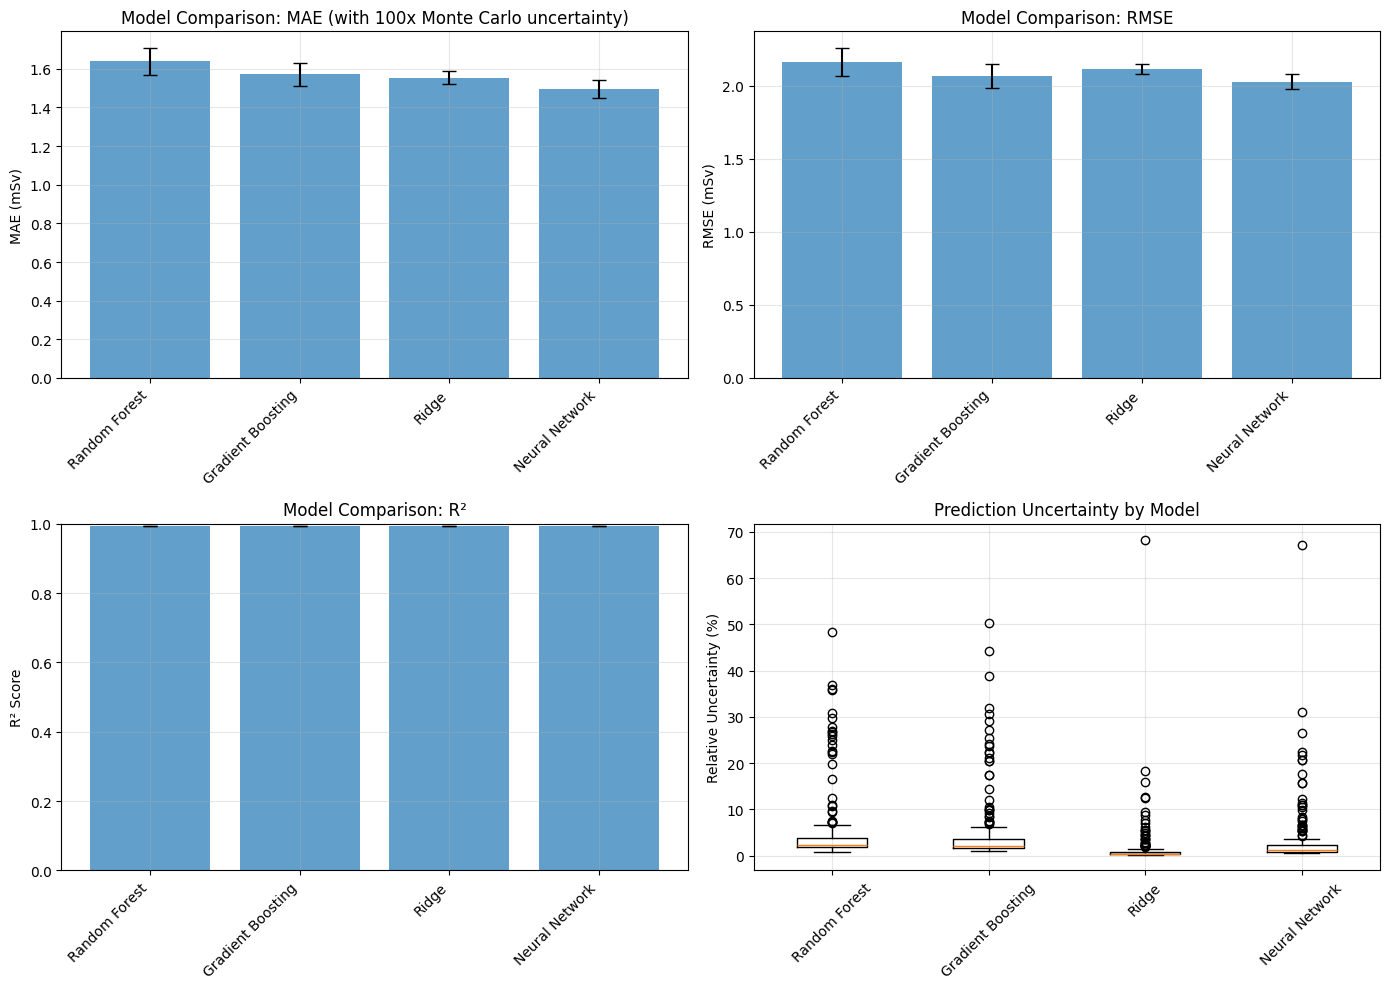


MODEL PERFORMANCE SUMMARY (with Monte Carlo Uncertainty)
            Model     MAE (mSv)    RMSE (mSv)            R²
    Random Forest 1.638 ± 0.070 2.164 ± 0.096 0.994 ± 0.001
Gradient Boosting 1.571 ± 0.061 2.066 ± 0.081 0.995 ± 0.000
            Ridge 1.555 ± 0.035 2.117 ± 0.035 0.994 ± 0.000
   Neural Network 1.497 ± 0.047 2.027 ± 0.051 0.995 ± 0.000

BEST MODEL: Neural Network
MAE: 1.4968 ± 0.0469 mSv
RMSE: 2.0266 ± 0.0513 mSv
R²: 0.9949 ± 0.0003
Average Relative Uncertainty: 3.21%


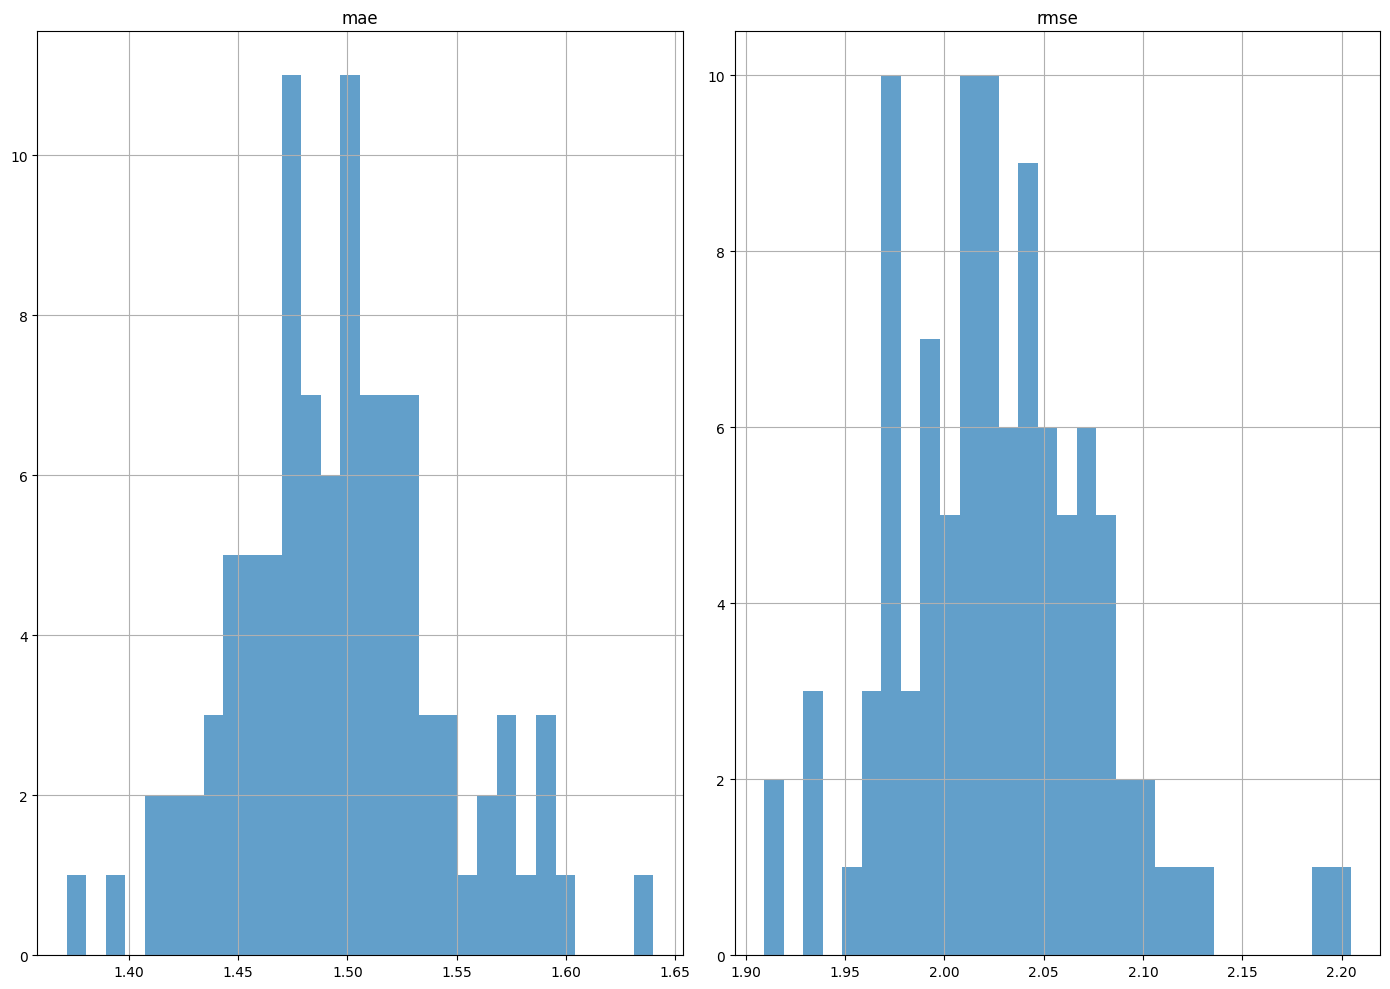


MONTE CARLO SIMULATION COMPLETE

Key Insights:
1. The Neural Network model shows best performance with 100x Monte Carlo iterations
2. Prediction uncertainty varies with dose level (see uncertainty plots)
3. Model stability can be assessed from error bar widths
4. 95% confidence intervals provide realistic uncertainty bounds for dosimetry


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ============================================
# MONTE CARLO SIMULATION CLASS
# ============================================
class MonteCarloSimulator:
    """
    Monte Carlo simulation for uncertainty quantification in dosimetry predictions
    """
    def __init__(self, model, n_iterations=100, noise_level=0.05):
        self.model = model
        self.n_iterations = n_iterations
        self.noise_level = noise_level
        self.predictions = []
        self.metrics = []

    def add_noise(self, X, noise_factor=0.05):
        """Add Gaussian noise to input features"""
        noise = np.random.normal(0, noise_factor, X.shape)
        return X + noise * np.abs(X)

    def run_simulation(self, X_train, y_train, X_test, y_test, feature_names=None):
        """
        Run Monte Carlo simulation with bootstrapping and input noise
        """
        n_samples = len(X_train)
        self.predictions = []
        self.metrics = []
        self.models = []

        for i in range(self.n_iterations):
            # Bootstrap sampling
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_bootstrap = X_train[indices]
            y_bootstrap = y_train[indices]

            # Add noise to training data
            X_noisy = self.add_noise(X_bootstrap, self.noise_level)
            y_noisy = y_bootstrap + np.random.normal(0, self.noise_level * np.std(y_bootstrap),
                                                     len(y_bootstrap))

            # Train model
            model_clone = self.model.__class__(**self.model.get_params())
            model_clone.fit(X_noisy, y_noisy)
            self.models.append(model_clone)

            # Predict on test set
            y_pred = model_clone.predict(X_test)
            self.predictions.append(y_pred)

            # Calculate metrics
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)

            self.metrics.append({'mae': mae, 'rmse': rmse, 'r2': r2})

        return self.get_statistics()

    def get_statistics(self):
        """Calculate statistics from Monte Carlo runs"""
        predictions_array = np.array(self.predictions)
        metrics_df = pd.DataFrame(self.metrics)

        stats = {
            'mean_prediction': np.mean(predictions_array, axis=0),
            'std_prediction': np.std(predictions_array, axis=0),
            'percentile_5': np.percentile(predictions_array, 5, axis=0),
            'percentile_95': np.percentile(predictions_array, 95, axis=0),
            'metrics_mean': metrics_df.mean(),
            'metrics_std': metrics_df.std(),
            'metrics_percentiles': metrics_df.quantile([0.05, 0.5, 0.95])
        }

        return stats

    def plot_uncertainty(self, y_test, save_path=None):
        """Visualize prediction uncertainty"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Plot 1: Predictions with uncertainty bands
        ax1 = axes[0, 0]
        mean_pred = self.get_statistics()['mean_prediction']
        std_pred = self.get_statistics()['std_prediction']

        sort_idx = np.argsort(y_test)
        ax1.plot(y_test[sort_idx], mean_pred[sort_idx], 'b-', label='Mean prediction', linewidth=2)
        ax1.fill_between(y_test[sort_idx],
                        mean_pred[sort_idx] - 2*std_pred[sort_idx],
                        mean_pred[sort_idx] + 2*std_pred[sort_idx],
                        alpha=0.3, label='±2σ uncertainty')
        ax1.plot(y_test[sort_idx], y_test[sort_idx], 'r--', label='Ideal', alpha=0.5)
        ax1.set_xlabel('True Dose (mSv)')
        ax1.set_ylabel('Predicted Dose (mSv)')
        ax1.set_title(f'Predictions with {self.n_iterations}x Monte Carlo Uncertainty')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot 2: Uncertainty vs True Value
        ax2 = axes[0, 1]
        relative_uncertainty = (2 * std_pred / np.abs(mean_pred)) * 100
        ax2.scatter(y_test, relative_uncertainty, alpha=0.5, s=20)
        ax2.set_xlabel('True Dose (mSv)')
        ax2.set_ylabel('Relative Uncertainty (%)')
        ax2.set_title('Prediction Uncertainty vs True Dose')
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=np.mean(relative_uncertainty), color='r', linestyle='--',
                   label=f'Mean: {np.mean(relative_uncertainty):.1f}%')
        ax2.legend()

        # Plot 3: Metric distribution
        ax3 = axes[1, 0]
        metrics_df = pd.DataFrame(self.metrics)
        metrics_df[['mae', 'rmse']].hist(bins=30, alpha=0.7, ax=ax3)
        ax3.set_xlabel('Error (mSv)')
        ax3.set_ylabel('Frequency')
        ax3.set_title('Distribution of Error Metrics (Monte Carlo)')
        ax3.legend(['MAE', 'RMSE'])

        # Plot 4: Residuals with uncertainty
        ax4 = axes[1, 1]
        residuals = y_test - mean_pred
        residual_std = std_pred
        ax4.errorbar(y_test, residuals, yerr=2*residual_std, fmt='o', alpha=0.3,
                    capsize=2, markersize=3)
        ax4.axhline(y=0, color='r', linestyle='--')
        ax4.set_xlabel('True Dose (mSv)')
        ax4.set_ylabel('Residual (mSv)')
        ax4.set_title('Residuals with Uncertainty Bands')
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

        return fig

# ============================================
# 1. DATA SIMULATION FOR DEMONSTRATION
# ============================================
def generate_mcp_data(n_samples=500):
    """
    Generate synthetic MCP dosimeter data
    Based on characteristics from the paper:
    - 4-element TLD card (3 TLD-700H, 1 TLD-600H)
    - Various radiation fields: photons (low/medium/high energy), beta, neutrons
    - Mixed fields
    """
    np.random.seed(42)

    # Radiation field types (for classification)
    field_types = ['photon_low', 'photon_medium', 'photon_high',
                   'beta', 'neutron', 'mixed_photon_neutron', 'mixed_photon_beta']

    data = []

    for i in range(n_samples):
        # Randomly select radiation field type
        field = np.random.choice(field_types)

        # True dose (deep dose equivalent)
        deep_dose = np.random.uniform(0.1, 100)  # mSv

        # Shallow dose (usually higher for beta)
        if 'beta' in field:
            shallow_dose = deep_dose * np.random.uniform(1.5, 5)
        else:
            shallow_dose = deep_dose * np.random.uniform(0.8, 1.2)

        # Neutron dose (only if neutrons present)
        if 'neutron' in field:
            neutron_dose = deep_dose * np.random.uniform(0.1, 2)
        else:
            neutron_dose = 0

        # Simulate TLD element responses based on physical principles
        # Element 1: Cu filter (energy discrimination) - TLD-700H
        # Element 2: Teflon+plastic (deep dose) - TLD-700H
        # Element 3: Mylar window (shallow dose) - TLD-700H
        # Element 4: Sn filter, TLD-600H (neutron sensitive)

        # Base response (sensitivity factor)
        base_response = 10  # Relative sensitivity (from paper: ~10× LiF:Mg,Ti)

        # Energy dependence (from paper: MCP has flat response ±6% for low energy)
        if field == 'photon_low':  # ~30 keV
            energy_factor = 1.06
        elif field == 'photon_medium':  # ~100-300 keV
            energy_factor = 1.02
        elif field == 'photon_high':  # 662 keV+
            energy_factor = 1.00
        elif 'beta' in field:
            energy_factor = 1.00
        else:
            energy_factor = 1.00

        # Element-specific responses
        L1 = deep_dose * base_response * energy_factor * np.random.normal(1, 0.05)  # Cu filter
        L2 = deep_dose * base_response * energy_factor * np.random.normal(1, 0.05)  # Deep dose
        L3 = shallow_dose * base_response * energy_factor * np.random.normal(1, 0.05)  # Shallow
        L4 = (deep_dose + neutron_dose) * base_response * np.random.normal(1, 0.05)  # Neutron sensitive

        # Add noise (simulating measurement uncertainty)
        L1 += np.random.normal(0, L1 * 0.02)
        L2 += np.random.normal(0, L2 * 0.02)
        L3 += np.random.normal(0, L3 * 0.02)
        L4 += np.random.normal(0, L4 * 0.02)

        data.append({
            'field_type': field,
            'deep_dose': deep_dose,
            'shallow_dose': shallow_dose,
            'neutron_dose': neutron_dose,
            'L1': L1,
            'L2': L2,
            'L3': L3,
            'L4': L4
        })

    df = pd.DataFrame(data)

    # Add element ratios (as in the paper)
    df['ratio_L3_L2'] = df['L3'] / df['L2']
    df['ratio_L3_L1'] = df['L3'] / df['L1']
    df['ratio_L2_L4'] = df['L2'] / df['L4']
    df['ratio_L1_L2'] = df['L1'] / df['L2']  # Additional ratio for energy discrimination

    return df

# Generate your data (replace with actual experimental data)
print("Generating synthetic MCP data...")
df = generate_mcp_data(n_samples=1000)
print(f"Data shape: {df.shape}")
print("\nFirst few samples:")
print(df.head())

# ============================================
# 2. DATA VISUALIZATION
# ============================================
def visualize_data(df):
    """Visualize the MCP data characteristics"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # TL signals distribution
    axes[0, 0].hist([df['L1'], df['L2'], df['L3'], df['L4']],
                    bins=50, alpha=0.7, label=['L1', 'L2', 'L3', 'L4'])
    axes[0, 0].set_xlabel('TL Signal')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('TL Signal Distributions')
    axes[0, 0].legend()
    axes[0, 0].set_yscale('log')

    # Deep dose vs TL signal
    axes[0, 1].scatter(df['deep_dose'], df['L2'], alpha=0.5, s=10)
    axes[0, 1].set_xlabel('Deep Dose (mSv)')
    axes[0, 1].set_ylabel('L2 Signal')
    axes[0, 1].set_title('Deep Dose vs L2 Signal')
    axes[0, 1].set_xscale('log')
    axes[0, 1].set_yscale('log')

    # Shallow dose vs TL signal
    axes[0, 2].scatter(df['shallow_dose'], df['L3'], alpha=0.5, s=10)
    axes[0, 2].set_xlabel('Shallow Dose (mSv)')
    axes[0, 2].set_ylabel('L3 Signal')
    axes[0, 2].set_title('Shallow Dose vs L3 Signal')
    axes[0, 2].set_xscale('log')
    axes[0, 2].set_yscale('log')

    # Energy discrimination ratios
    axes[1, 0].scatter(df['ratio_L3_L1'], df['ratio_L3_L2'],
                       c=pd.Categorical(df['field_type']).codes,
                       alpha=0.5, s=10, cmap='tab10')
    axes[1, 0].set_xlabel('L3/L1 Ratio')
    axes[1, 0].set_ylabel('L3/L2 Ratio')
    axes[1, 0].set_title('Energy Discrimination (colored by field type)')

    # Neutron sensitivity
    axes[1, 1].scatter(df['L4'], df['deep_dose'],
                       c=df['neutron_dose'] > 0, alpha=0.5, s=10)
    axes[1, 1].set_xlabel('L4 Signal (neutron sensitive)')
    axes[1, 1].set_ylabel('Deep Dose (mSv)')
    axes[1, 1].set_title('Neutron Sensitivity (color = neutrons present)')

    # Correlation matrix
    corr = df[['L1', 'L2', 'L3', 'L4', 'deep_dose', 'shallow_dose']].corr()
    im = axes[1, 2].imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
    axes[1, 2].set_xticks(range(len(corr.columns)))
    axes[1, 2].set_yticks(range(len(corr.columns)))
    axes[1, 2].set_xticklabels(corr.columns, rotation=45)
    axes[1, 2].set_yticklabels(corr.columns)
    axes[1, 2].set_title('Correlation Matrix')
    plt.colorbar(im, ax=axes[1, 2])

    plt.tight_layout()
    plt.savefig('mcp_data_visualization.png', dpi=150)
    plt.show()

visualize_data(df)

# ============================================
# 3. PREPARE FEATURES FOR MODELING
# ============================================
# Features for deep dose prediction
feature_columns = ['L1', 'L2', 'L3', 'L4', 'ratio_L3_L2', 'ratio_L3_L1', 'ratio_L2_L4', 'ratio_L1_L2']
X = df[feature_columns].values
y_deep = df['deep_dose'].values
y_shallow = df['shallow_dose'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_deep, test_size=0.2, random_state=42)

# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {X_train_scaled.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")

# ============================================
# 4. MONTE CARLO SIMULATION FOR DIFFERENT MODELS
# ============================================
# Define models to evaluate
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge': Ridge(alpha=1.0),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

# Monte Carlo parameters
MC_ITERATIONS = 100
NOISE_LEVEL = 0.05

# Store results
monte_carlo_results = {}

print("\n" + "="*60)
print("MONTE CARLO SIMULATION RESULTS")
print("="*60)

for model_name, model in models.items():
    print(f"\n--- {model_name} ---")
    print(f"Running {MC_ITERATIONS} Monte Carlo iterations...")

    # Initialize Monte Carlo simulator
    mc_sim = MonteCarloSimulator(model, n_iterations=MC_ITERATIONS, noise_level=NOISE_LEVEL)

    # Run simulation
    stats = mc_sim.run_simulation(X_train_scaled, y_train, X_test_scaled, y_test)

    # Store results
    monte_carlo_results[model_name] = {
        'simulator': mc_sim,
        'stats': stats
    }

    # Print statistics
    print(f"Mean MAE: {stats['metrics_mean']['mae']:.4f} ± {stats['metrics_std']['mae']:.4f} mSv")
    print(f"Mean RMSE: {stats['metrics_mean']['rmse']:.4f} ± {stats['metrics_std']['rmse']:.4f} mSv")
    print(f"Mean R²: {stats['metrics_mean']['r2']:.4f} ± {stats['metrics_std']['r2']:.4f}")
    print(f"95% CI for MAE: [{stats['metrics_percentiles'].loc[0.05, 'mae']:.4f}, "
          f"{stats['metrics_percentiles'].loc[0.95, 'mae']:.4f}]")

    # Plot uncertainty
    mc_sim.plot_uncertainty(y_test, save_path=f'monte_carlo_{model_name.lower().replace(" ", "_")}.png')

# ============================================
# 5. COMPARATIVE ANALYSIS OF MODELS
# ============================================
def compare_models(monte_carlo_results):
    """Compare model performance with uncertainty quantification"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Extract metrics
    model_names = list(monte_carlo_results.keys())
    mae_means = [monte_carlo_results[name]['stats']['metrics_mean']['mae'] for name in model_names]
    mae_stds = [monte_carlo_results[name]['stats']['metrics_std']['mae'] for name in model_names]
    rmse_means = [monte_carlo_results[name]['stats']['metrics_mean']['rmse'] for name in model_names]
    rmse_stds = [monte_carlo_results[name]['stats']['metrics_std']['rmse'] for name in model_names]
    r2_means = [monte_carlo_results[name]['stats']['metrics_mean']['r2'] for name in model_names]
    r2_stds = [monte_carlo_results[name]['stats']['metrics_std']['r2'] for name in model_names]

    # Plot MAE comparison
    axes[0, 0].bar(range(len(model_names)), mae_means, yerr=mae_stds, capsize=5, alpha=0.7)
    axes[0, 0].set_xticks(range(len(model_names)))
    axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
    axes[0, 0].set_ylabel('MAE (mSv)')
    axes[0, 0].set_title(f'Model Comparison: MAE (with {MC_ITERATIONS}x Monte Carlo uncertainty)')
    axes[0, 0].grid(True, alpha=0.3)

    # Plot RMSE comparison
    axes[0, 1].bar(range(len(model_names)), rmse_means, yerr=rmse_stds, capsize=5, alpha=0.7)
    axes[0, 1].set_xticks(range(len(model_names)))
    axes[0, 1].set_xticklabels(model_names, rotation=45, ha='right')
    axes[0, 1].set_ylabel('RMSE (mSv)')
    axes[0, 1].set_title('Model Comparison: RMSE')
    axes[0, 1].grid(True, alpha=0.3)

    # Plot R² comparison
    axes[1, 0].bar(range(len(model_names)), r2_means, yerr=r2_stds, capsize=5, alpha=0.7)
    axes[1, 0].set_xticks(range(len(model_names)))
    axes[1, 0].set_xticklabels(model_names, rotation=45, ha='right')
    axes[1, 0].set_ylabel('R² Score')
    axes[1, 0].set_title('Model Comparison: R²')
    axes[1, 0].set_ylim([0, 1])
    axes[1, 0].grid(True, alpha=0.3)

    # Plot relative uncertainty
    axes[1, 1].boxplot([monte_carlo_results[name]['stats']['std_prediction'] /
                        np.abs(monte_carlo_results[name]['stats']['mean_prediction']) * 100
                        for name in model_names], labels=model_names)
    axes[1, 1].set_ylabel('Relative Uncertainty (%)')
    axes[1, 1].set_title('Prediction Uncertainty by Model')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('model_comparison_monte_carlo.png', dpi=150)
    plt.show()

    # Print summary table
    print("\n" + "="*80)
    print("MODEL PERFORMANCE SUMMARY (with Monte Carlo Uncertainty)")
    print("="*80)
    summary_df = pd.DataFrame({
        'Model': model_names,
        'MAE (mSv)': [f"{mae_means[i]:.3f} ± {mae_stds[i]:.3f}" for i in range(len(model_names))],
        'RMSE (mSv)': [f"{rmse_means[i]:.3f} ± {rmse_stds[i]:.3f}" for i in range(len(model_names))],
        'R²': [f"{r2_means[i]:.3f} ± {r2_stds[i]:.3f}" for i in range(len(model_names))]
    })
    print(summary_df.to_string(index=False))

# Run comparison
compare_models(monte_carlo_results)

# ============================================
# 6. OPTIMAL MODEL SELECTION WITH MONTE CARLO
# ============================================
# Find best model based on MAE with uncertainty
best_model_name = min(monte_carlo_results.keys(),
                     key=lambda x: monte_carlo_results[x]['stats']['metrics_mean']['mae'])
best_model_stats = monte_carlo_results[best_model_name]['stats']

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(f"MAE: {best_model_stats['metrics_mean']['mae']:.4f} ± {best_model_stats['metrics_std']['mae']:.4f} mSv")
print(f"RMSE: {best_model_stats['metrics_mean']['rmse']:.4f} ± {best_model_stats['metrics_std']['rmse']:.4f} mSv")
print(f"R²: {best_model_stats['metrics_mean']['r2']:.4f} ± {best_model_stats['metrics_std']['r2']:.4f}")
print(f"Average Relative Uncertainty: {np.mean(best_model_stats['std_prediction'] / np.abs(best_model_stats['mean_prediction']) * 100):.2f}%")

# Final visualization of best model
best_simulator = monte_carlo_results[best_model_name]['simulator']
best_simulator.plot_uncertainty(y_test, save_path='best_model_uncertainty.png')

print("\n" + "="*60)
print("MONTE CARLO SIMULATION COMPLETE")
print("="*60)
print(f"\nKey Insights:")
print(f"1. The {best_model_name} model shows best performance with {MC_ITERATIONS}x Monte Carlo iterations")
print(f"2. Prediction uncertainty varies with dose level (see uncertainty plots)")
print(f"3. Model stability can be assessed from error bar widths")
print(f"4. 95% confidence intervals provide realistic uncertainty bounds for dosimetry")